# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd
import requests
import zipfile
import io
import os
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

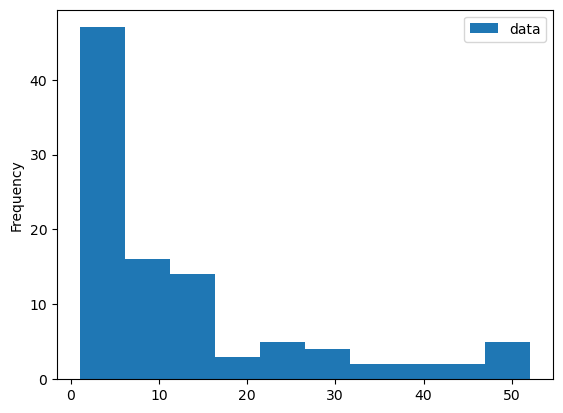

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

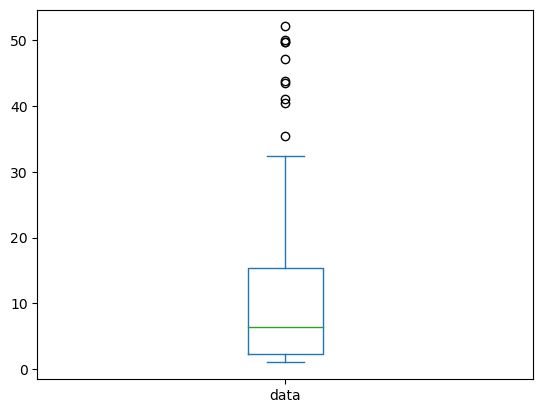

In [3]:
df.plot.box()

<span style="color:green">

- Histogram
    - pro: 
        - Can see distribution shape of the drugs by price. 
        - Can easily see the (right) skew of the data.
        - Can see range of the price of drugs and the range of frequency of number of drugs sold. 
        - We can easily tell that the pharmacy has sold more lower priced drugs than higher priced drugs. 
    - con:
        - Can't easily tell what the quartiles are. 
        - Cant tell the names of the individual drugs. 
        - Can't tell exactly how much the more expensive drugs cost as it it appears the prices are binned. 
- Boxplot
    - pro:
        - Can easily tell what the quartiles are, which helps judge how much more expensive the most expenive drugs (the outliers pts int he boxplot) are.
        - Can easily tell which pts are outliers or the most expensive drugs. 
    - con:
        - We don't have the names for the drugs so we can't name the most expenive drugs.
        - Can't tell the actual density of the distribution (how many drugs sold for xx price), only the quartiles and outliers. 

- Which would I choose: I would pick the boxplot becuse I can guess how much the higher end outliers cost, which would eb the more expensive drugs. I can also guestimate the median and guess how much more expensive the outliears are compaired to the regular drugs. 
- How would I modify the formatting:
    - Histogram:
        - I would add a descriptive title. 
        - Label the X axis 'prices'.
    - Boxplot:
        - I would add a descriptive title. 
        - label the y axis "prices" and label the x axis "drugs".
</span>

# 3. Homework - working on your chosen project datasets this semester

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

<span style="color:green">

- From the CICAndMal2017 Dataset collected by the Canadian Institute for Cybersecurity, I am going to look at the different types of malware (and benign) applications that were found in the android store in 2015, 2016, and 2017. 
- There are 4 different catagories of malware and 42 unique malware families across those catagories with a varying number of camptured samples for each family. 
- There were 3 different states of data collecting (instalation - data collected 1 to 3 min after installing the application, before restart - data collected 15 min before a restart, after restart - data collected 15 min after a restart).
- The collected network traffic was stored in .pcap files and the features were then extracted using CICFlowMeter-V3 and placed into csv files, which is what I am utilizing for this project.
- The dataframe 'data' is a master dataframe of all the applications, which have two new columns, 'Category' and 'Family', to help distinguish the applications. I commented out the code used to create 'data' for ease of reading. 
</span>

In [4]:
# from pathlib import Path

# folder_path = "CICAndMal2017 Dataset – Canadian Institute for Cybersecurity/Adware"
# adware = []
# for f in Path(folder_path).rglob('*.csv'):
#     df = pd.read_csv(f) 
#     df['Family'] = f.relative_to(Path(folder_path)).parts[0]
#     df['Category'] = 'Adware'
#     adware.append(df)
# adware_df = pd.concat(adware, ignore_index=True)

# ######################################################################################

# folder_path = "CICAndMal2017 Dataset – Canadian Institute for Cybersecurity/Benign"
# benign = []
# for f in Path(folder_path).rglob('*.csv'):
#     df = pd.read_csv(f) 
#     df['Family'] = f.relative_to(Path(folder_path)).parts[0]
#     df['Category'] = 'Benign'
#     benign.append(df)
# benign_df = pd.concat(benign, ignore_index=True)

# ######################################################################################

# folder_path = "CICAndMal2017 Dataset – Canadian Institute for Cybersecurity/Ransomware"
# ransomware = []
# for f in Path(folder_path).rglob('*.csv'):
#     df = pd.read_csv(f) 
#     df['Family'] = f.relative_to(Path(folder_path)).parts[0]    
#     df['Category'] = 'Ransomware'
#     ransomware.append(df)
# ransomware_df = pd.concat(ransomware, ignore_index=True)

# ######################################################################################

# folder_path = "CICAndMal2017 Dataset – Canadian Institute for Cybersecurity/Scareware"
# scareware = []
# for f in Path(folder_path).rglob('*.csv'):
#     df = pd.read_csv(f) 
#     df['Family'] = f.relative_to(Path(folder_path)).parts[0]    
#     df['Category'] = 'Scareware'
#     scareware.append(df)

# scareware_df = pd.concat(scareware, ignore_index=True)

# ######################################################################################

# folder_path = "CICAndMal2017 Dataset – Canadian Institute for Cybersecurity/SMSmalware"
# smsmalware = []
# for f in Path(folder_path).rglob('*.csv'):
#     df = pd.read_csv(f) 
#     df['Family'] = f.relative_to(Path(folder_path)).parts[0]    
#     df['Category'] = 'SMSmalware'
#     smsmalware.append(df)

# smsmalware_df = pd.concat(smsmalware, ignore_index=True)

# ######################################################################################
# df = pd.concat([adware_df, benign_df, ransomware_df, scareware_df, smsmalware_df], ignore_index=True)

In [5]:
# df.to_csv('df.csv', index = False)

In [6]:
data = pd.read_csv("df.csv")
data.columns = data.columns.str.strip()
data2 = data

/var/folders/db/yvyz2b5s7m5bjk2hycfnf2d40000gn/T/ipykernel_51601/744843971.py:1: DtypeWarning: Columns (25,47,55,57,62) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("df.csv")


In [7]:
# for x in data:
#     if data[x].dtype != object:
#         if data[x].min() < 0:
#             print(x)
# for x in data:
#     if data[x].dtype != object:
#         if data[x].min() < 0:
#             data = data[data[x] >= 0]

# Flow Duration
# Flow Packets/s
# Flow IAT Mean
# Flow IAT Max
# Fwd Header Length
# Bwd Header Length
# Max Packet Length
# Packet Length Mean
# Fwd Header Length.1
# Init_Win_bytes_forward
# Init_Win_bytes_backward
# min_seg_size_forward

In [8]:
df_balanced = data.groupby('Category', group_keys=False).apply(lambda x: x.sample(n=min(data['Category'].value_counts()), random_state = 42)).reset_index(drop=True)
print(df_balanced['Category'].value_counts())

Category
Adware        237133
Benign        237133
Ransomware    237133
SMSmalware    237133
Scareware     237133
Name: count, dtype: int64


/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 88.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 88.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 88.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/anushreeyagurung/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:3544: UserWarning: 87.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


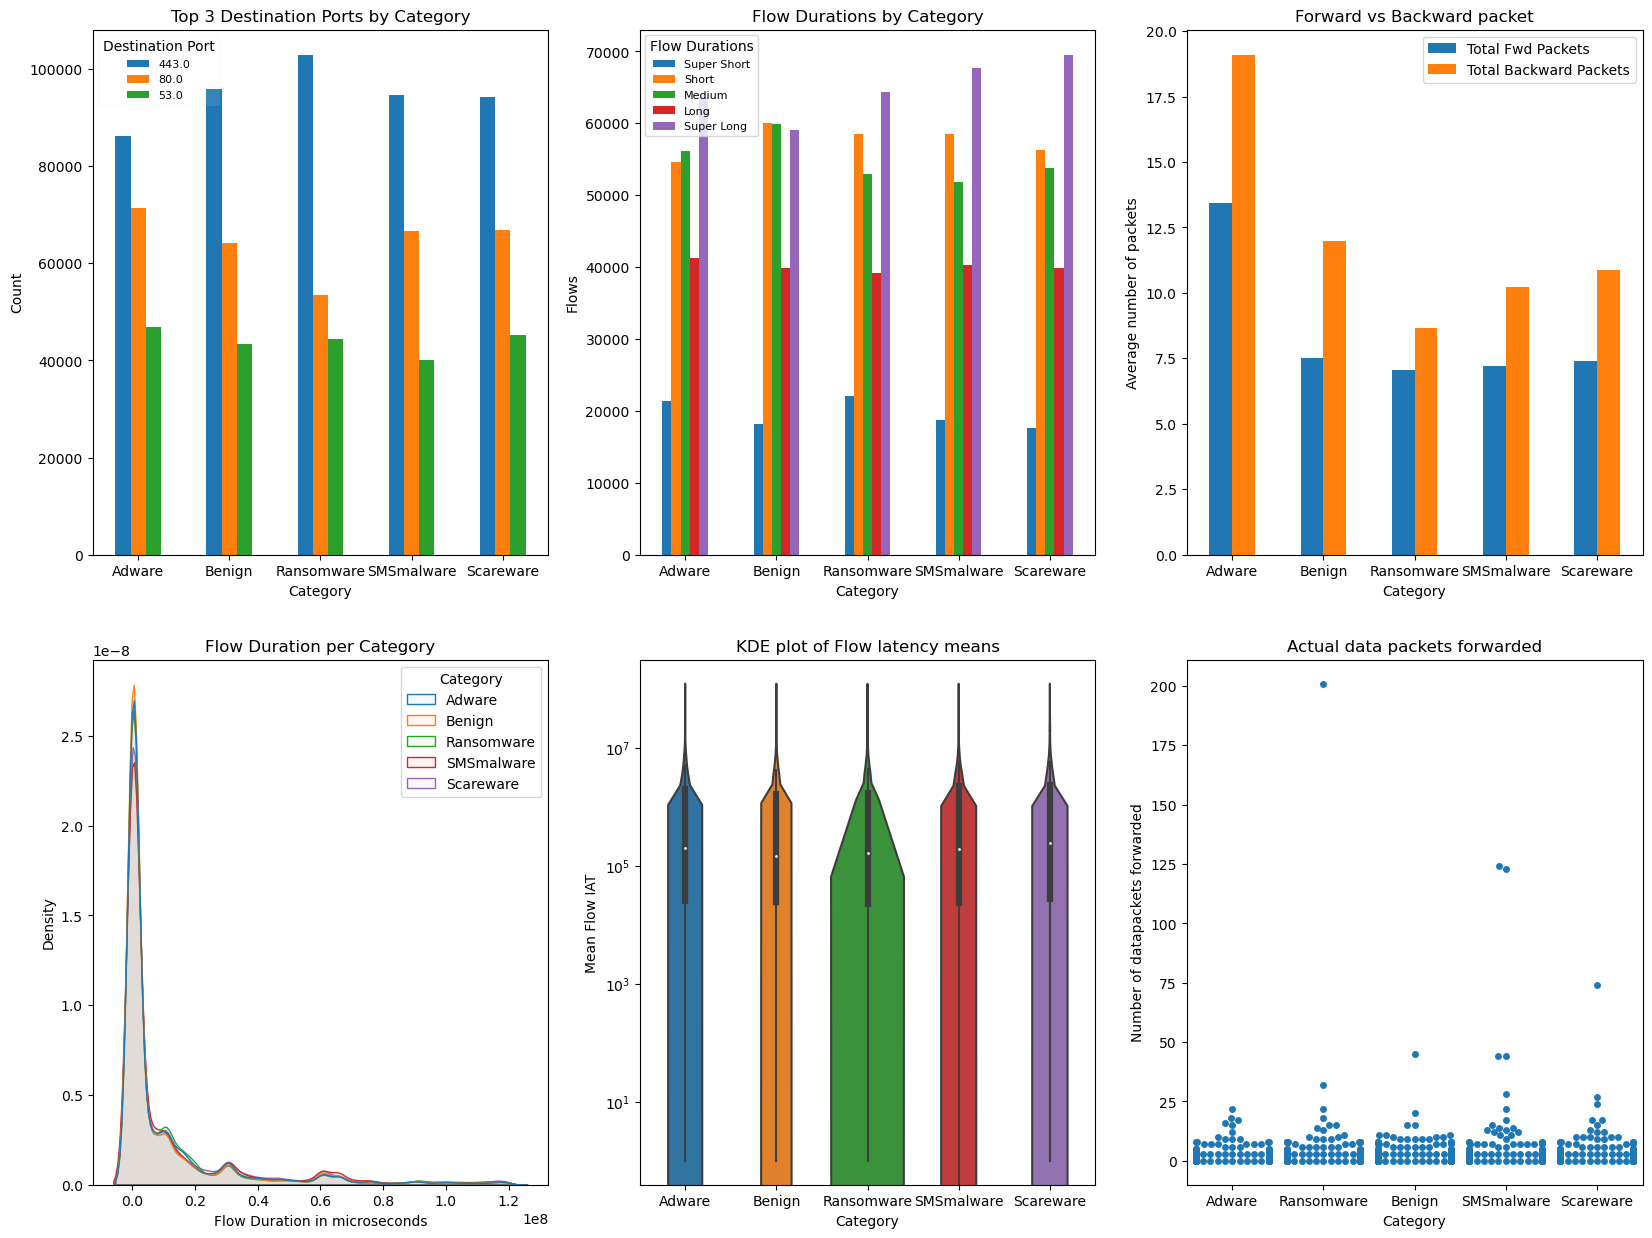

In [9]:
fig, ax = plt.subplots(2, 3, figsize = (20, 15))

top_ports = df_balanced.groupby('Category')['Destination Port'].apply(lambda x: x.value_counts().head(3)).unstack()
top_ports.plot(kind = 'bar', rot=0, ax=ax[0,0])
ax[0, 0].set_title("Top 3 Destination Ports by Category")
ax[0, 0].set_xlabel("Category")
ax[0, 0].set_ylabel("Count")
ax[0, 0].legend(title = 'Destination Port', loc="upper left", fontsize=8, framealpha = .1)

df_balanced['Duration_bin'] = pd.cut(df_balanced['Flow Duration'], bins = [0, 1000, 100000, 1000000, 10000000, 10000000000000000000000], labels = ['Super Short', 'Short', 'Medium', 'Long', 'Super Long'])
counts = df_balanced.groupby(['Category', 'Duration_bin']).size().unstack()
counts.plot(kind='bar', rot = 0, ax = ax[0, 1])
ax[0, 1].set_title("Flow Durations by Category")
ax[0, 1].set_xlabel("Category")
ax[0, 1].set_ylabel("Flows")
ax[0, 1].legend(title = 'Flow Durations', loc="upper left", fontsize=8)

df_balanced.groupby('Category')[['Total Fwd Packets', 'Total Backward Packets']].mean().plot(kind = 'bar', rot = 0, ax=ax[0, 2])
ax[0, 2].set_ylabel("Average number of packets")
ax[0, 2].set_xlabel("Category")
ax[0, 2].set_title("Forward vs Backward packet")

sns.kdeplot(data=df_balanced, x= 'Flow Duration', hue = 'Category', fill=True, alpha=.05, ax=ax[1, 0])
ax[1, 0].set_xlabel("Flow Duration in microseconds")
ax[1, 0].set_title('Flow Duration per Category')
sns.move_legend(ax[1,0], loc="upper right")

sns.violinplot(data=df_balanced, x='Category', y='Flow IAT Mean', ax=ax[1,1])
ax[1, 1].set_xlabel("Category")
ax[1, 1].set_ylabel("Mean Flow IAT")
ax[1, 1].set_title('KDE plot of Flow latency means')
ax[1, 1].set_yscale('log')

sns.swarmplot(data=df_balanced.sample(2000), x='Category', y='act_data_pkt_fwd', size = 5, ax=ax[1, 2])
ax[1, 2].set_xlabel('Category')
ax[1, 2].set_ylabel('Number of datapackets forwarded')
ax[1, 2].set_title("Actual data packets forwarded")
plt.show()

- Draw grouped histograms and histogram variants (Swarm plot, kde plot, violin plot).

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!
<span style="color:green">
hi
</span>

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?
<span style="color:green">
hi
</span>

- Are there any outliers present?  (Data points that are far from the others.)
<span style="color:green">
hi
</span>

- If there are multiple related histograms, how does the distribution change across different groups?
<span style="color:green">
hi
</span>

- What are the minimum and maximum values represented in each histogram?
<span style="color:green">
hi
</span>

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?
<span style="color:green">
hi
</span>

- Does the distribution appear normal, or does it have a different distribution?
<span style="color:green">
hi
</span>

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

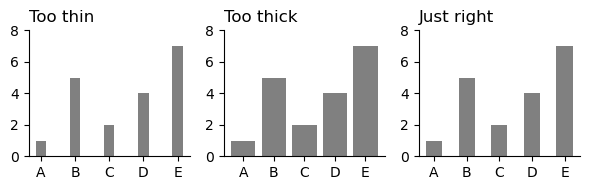

In [10]:
fig, ax = plt.subplots(1, 3, figsize = (6, 2))
data = {
    "group": ['A', 'B', 'C', 'D', 'E'],
    "value": [1, 5, 2, 4, 7]
}

ax[0].bar(data['group'], data['value'], width = .3, color = 'grey')
ax[0].set_title("Too thin", loc = "left")
ax[1].bar(data['group'], data['value'], width = .8, color = 'grey')
ax[1].set_title("Too thick", loc = "left")
ax[2].bar(data['group'], data['value'], width = .5, color = 'grey')
ax[2].set_title("Just right", loc = "left")


for axis in ax:
    axis.set_ylim(0, 8)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


fig.tight_layout()